In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import scipy

from matplotlib import patheffects

plt.rcParams['path.effects'] =[
            patheffects.withStroke(linewidth=4, foreground="w", joinstyle="round")]

In [2]:
programs = dict()

for file in os.listdir("./survey_responses"):
    name = file.split("-")[0].replace(" and ", "").replace(" ", "").replace("Survey", "")

    programs[name] = pd.read_csv("./survey_responses/" + file, sep='\t')

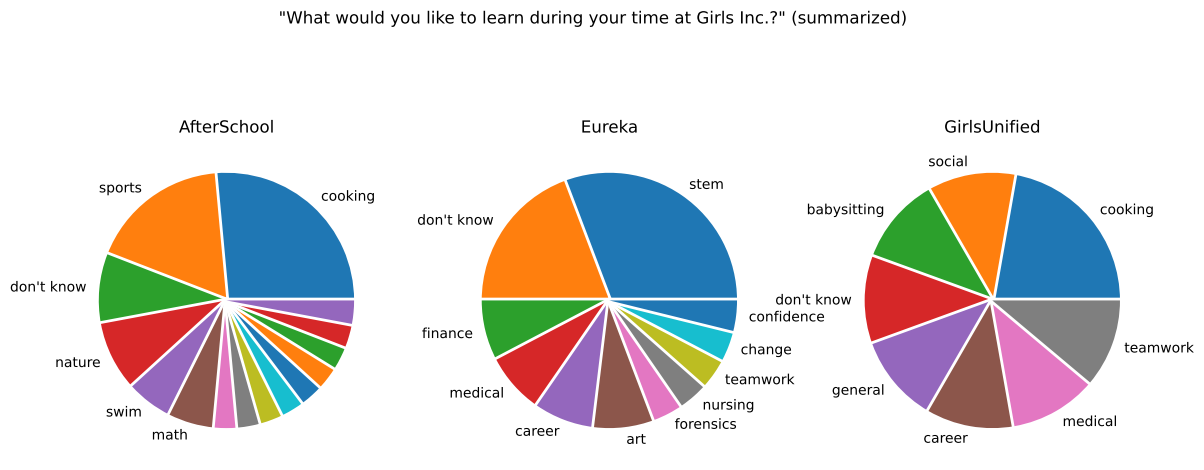

In [3]:
fig = plt.figure(figsize=(14, 6), dpi=100)
fig.suptitle("\"What would you like to learn during your time at Girls Inc.?\" (summarized)")

plots = fig.subplots(1, len(programs))

for (i, (k, df)) in enumerate(programs.items()):
    plt.rcParams.update({'font.size': 10})
    counts = df['manual_added_liketolearn_enum'].str.split(",").explode().str.replace("_", " ").value_counts()
    if counts.size > 12:
        counts = counts.rename({ k: "" for k in counts[counts == 1].index})
    counts = counts.rename({"nothing": "don't know"})
    counts.plot.pie(ax=plots[i], )
    plots[i].set_ylabel("")
    plots[i].set_title(k)

manual_added_addprogramming_enum
nothing      7
general      5
cooking      3
change       3
sports       3
food         1
respect      1
beauty       1
unknown      1
math         1
crafts       1
teamwork     1
gardening    1
stem         1
reading      1
art          1
Name: count, dtype: int64


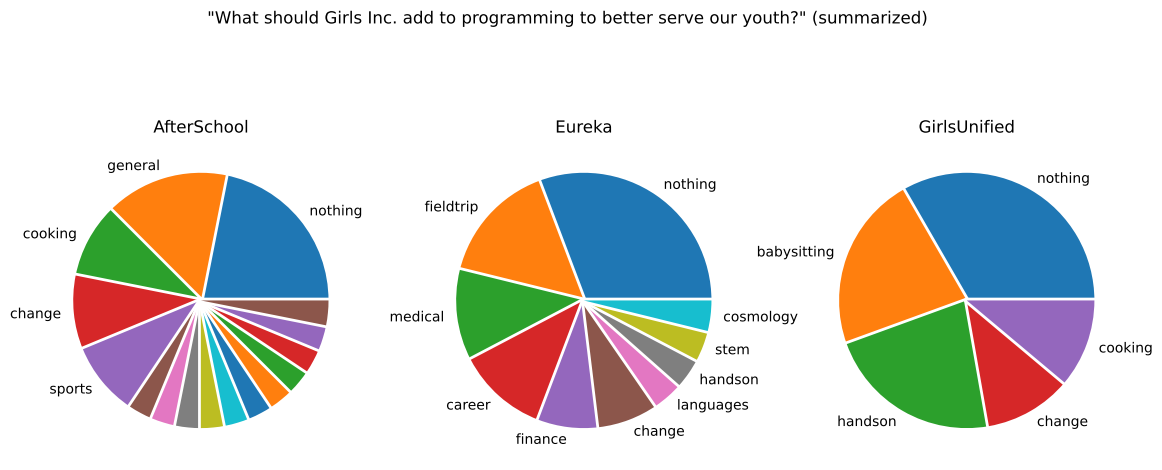

In [4]:
fig = plt.figure(figsize=(14, 6), dpi=100)
fig.suptitle("\"What should Girls Inc. add to programming to better serve our youth?\" (summarized)")

plots = fig.subplots(1, len(programs))

for (i, (k, df)) in enumerate(programs.items()):
    plt.rcParams.update({'font.size': 10})
    counts = df['manual_added_addprogramming_enum'].str.split(",").explode().str.replace("_", " ").value_counts()
    if counts.size > 12:
        print(counts)
        counts = counts.rename({ k: "" for k in counts[counts == 1].index})
    counts.plot.pie(ax=plots[i], )
    plots[i].set_ylabel("")
    plots[i].set_title(k)

In [10]:
advanced_course_completion = pd.read_csv("./Advanced_Course_Completion_20260420.csv")
advanced_course_completion['ADV_COMP_CNT'] = pd.to_numeric(advanced_course_completion['ADV_COMP_CNT'].str.replace(",", ""), errors='raise')
advanced_course_completion['G11_G12_CNT'] = pd.to_numeric(advanced_course_completion['G11_G12_CNT'].str.replace(",", ""), errors='raise')

for col in advanced_course_completion.columns:
    if col.endswith("_PCT"):
        advanced_course_completion[col] = pd.to_numeric(advanced_course_completion[col].str.replace("%", ""), errors='raise') / 100.0

/tmp/ipykernel_2586923/3508116612.py:1: DtypeWarning: Columns (0: ADV_CIS_PCT) have mixed types. Specify dtype option on import or set low_memory=False.
  advanced_course_completion = pd.read_csv("./Advanced_Course_Completion_20260420.csv")


In [11]:
schools_data = advanced_course_completion[(advanced_course_completion['ORG_TYPE'] == 'School') & ((advanced_course_completion['STU_GRP'] == 'Male') | (advanced_course_completion['STU_GRP'] == 'Female') | (advanced_course_completion['STU_GRP'] == 'All Students'))]
recent_data = schools_data.fillna(0)[(schools_data['SY'] > 2020) & (schools_data['ADV_COMP_CNT'] > 20) ]

recent_data['Stem'] = (recent_data['ADV_MATH_PCT'] + recent_data['ADV_SCI_PCT'] + recent_data['ADV_CIS_PCT']) 
recent_data['NonStem'] = (recent_data['ADV_HSS_PCT'] + recent_data['ADV_ART_PCT'] + recent_data['ADV_OTHER_PCT']) 


recent_data['Stem Dominance'] =  recent_data['Stem'] - recent_data['NonStem']

3.2565549336111617e-43
2.548234305304285e-27


Text(0, 0.5, 'Advanced Course Participation Rate')

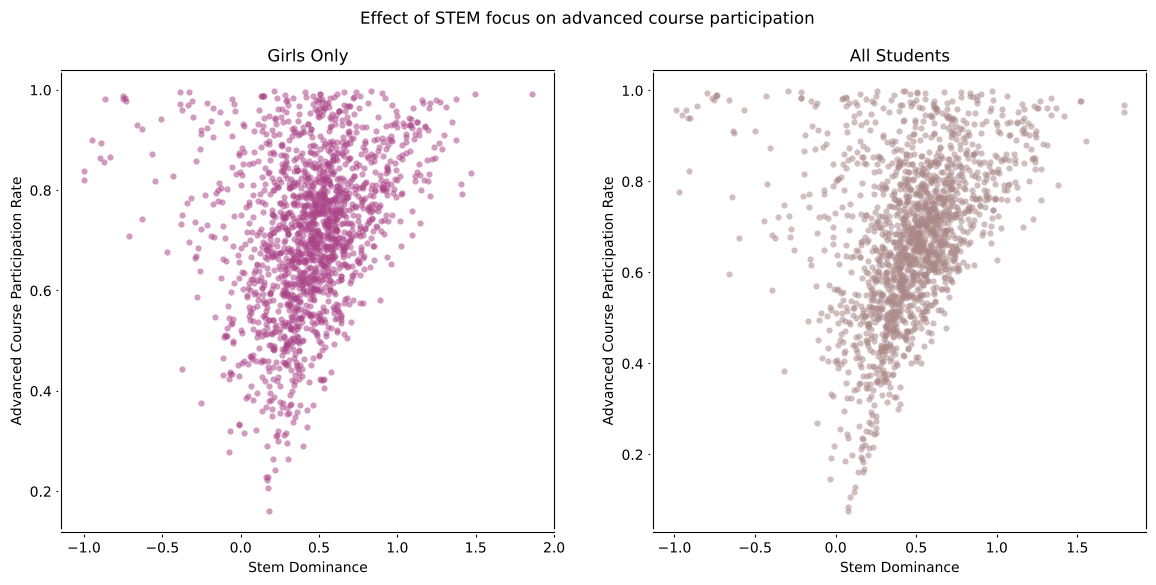

In [12]:
def plot_acc_data(data, x, y, ax, color='#a888', title='', slope=2):
    data = data.fillna({x: 0, y: 0})
    data = data[(data[y] < 1) & (data[y] > 0)]

    regression = scipy.stats.linregress(data[x], data[y])

    #regression = np.polyfit(data[x], data[y], 1)
    #p = np.poly1d(regression)
    #px = np.linspace(data[x].min(), data[x].max(), 100)

    data.plot.scatter(x=x, y=y, ax=ax, linewidth=0, color=color, title=title)

    #py = p(px)
    #ax.plot(px[py < 1], py[py < 1])

    #ax.annotate("Illustrative only", (0,0))
    #ax.axline((0, 0), (0, 1), color=color)
    slope = data[x].median() / data[y].median()

    
    #ax.axline((0, 0), slope=slope, color=color)
    print(regression.pvalue)

fig = plt.figure(figsize=(14, 6), dpi=100)
fig.suptitle("Effect of STEM focus on advanced course participation")

x = 'Stem Dominance'
y = 'ADV_COMP_PCT'

plots = fig.subplots(1, 2)

plot_acc_data(data=recent_data[recent_data['STU_GRP'] == "All Students"], x=x, y=y, ax=plots[1], color='#a888', title="All Students")
plots[1].set_ylabel("Advanced Course Participation Rate")

plot_acc_data(data=recent_data[recent_data['STU_GRP'] == "Female"], x=x, y=y, ax=plots[0], color='#a488', title="Girls Only")
plots[0].set_ylabel("Advanced Course Participation Rate")